# KCORC Summer School: TESPy Workshop
## Case Study: Double-stage R1233ZD(E) Heat Pump system -- for geothermal district heating supply

### Introduction

With the growing product range of large-scale heat pump systems, the use
of medium-deep geothermal energy has gained increasing attention over the
last years. E.g., the Energie-Wende-Garching (EWG) next to the TUM campus
has recently installed an ammonia heat pump (2 x 2.6 MW) to increase the
thermal capacity of the geothermal project.

In addition, more and more municipalities with rather low achievable
brine temperatures (e.g. 40 to 60 degC) consider using large-scale heat
pumps to upgrade the temperature level to the required district heating
supply temperatures (e.g. 90 degC). The figure below displays that the
utilization of such low- and medium-temperature resources significantly
increases the potential regions for geothermal applications. E.g. in the
northern areas of Munich.

![Figure 1: Geothermal temperature distribution in Germany](../geothermal_utilization.png)

*Figure 1: Geothermal temperature distribution in Germany (taken from Moeck et al. 2020)*

Against this background, the case study investigates a potential
R1233ZD(E) case study for a typical medium deep project. Similar to a
feasibility study for a potential geothermal heat pump project in
Schwerin (cf. Mathes et al. 2022), this workshop exercise reconstructs
that problem as a two-loop R1233zd(E) heat pump system. As shown in
Figure 2, they are fully independent heat pumps that share the
geothermal and district-heating water streams in series.

![Figure 2: Scheme of the proposed R1233ZD(E) heat pumps](../hp.svg)

*Figure 2: Scheme of the proposed R1233ZD(E) heat pumps, with connection labels b01-b05 (LT loop) and c01-c05 (HT loop)*

---

### This notebook

This notebook builds the **LT loop only** of a two-loop heat pump system.

```
geo intermediate (50 degC, from HT-evaporator) -> LT Evaporator -> geo injection (40 degC)

 1  -> LT compressor suction   (sat. vapour + superheat, low pressure)
 2  -> LT compressor discharge (superheated, high pressure)
 3  -> LT condenser outlet     (subcooled liquid, high pressure)
 4  -> LT expansion valve outlet -> LT evaporator inlet (low pressure, two-phase)
 1  -> closes the cycle at the LT evaporator outlet

DH return (60 degC, real) -> LT condenser (cold side) -> DH intermediate (75 degC, to HT-condenser)
```

The **LT loop is the one built here**, and it is the cooler of the two
(evaporates at 35 degC, condenses at 80 degC). It is responsible for the
**second (cooler) half of the geothermal glide**, 50 -> 40 degC, and sits
**first** in the district-heating line (receiving the real 60 degC return,
handing off an intermediate 75 degC to the HT loop). The HT loop is the
hotter of the two (evaporates at 45 degC, condenses at 95 degC), responsible
for the **first (warmer) half of the geothermal glide**, 60 -> 50 degC,
touching the real 60 degC production water directly and delivering the
real 90 degC supply target.

**Design point** (constant-efficiency compressor, `eta_s = 0.75`):

| | LT loop (this notebook) | HT loop (follow-up) |
|---|---|---|
| Evaporates at | 35 degC | 45 degC |
| Condenses at | 80 degC | 95 degC |
| Geothermal segment | 50 -> 40 degC | 60 -> 50 degC |
| Pressure ratio | approx 3.58 | approx 3.70 |


**What is fixed vs. a result in this notebook**: the geothermal side is now
**fully fixed**, inlet (50 degC), outlet (40 degC, the real injection
limit) and mass flow (100 kg/s) are all given directly, since the 50/40
split point is a genuine design choice (LT's own share of the geothermal
resource), not something left for the solver to find. On the
district heating side, both temperatures are fixed (60 degC real return,
75 degC placeholder outlet to the HT loop) but the **mass flow is left
free** and it becomes a result of the condenser's energy balance, once the
refrigerant mass flow is already known from the (fully-specified)
geothermal/evaporator side.


## Given:

**Table 1: Design Conditions**

| Connection | Category | Parameter              | LT loop (provided) | HT loop         |
|---|---|------------------------|--------------------|-----------------|
| - | Working fluid | Fluid                  | R1233ZD(E)         | R1233ZD(E)      |
| b04 -> b01  /  c04 -> c01 | Evaporator | Saturation temperature | 35 degC            | 45 degC         |
| b01  /  c01 | | Superheat              | 5 K                | 5 K             |
| b02 -> b03  /  c02 -> c03 | Condenser | Saturation temperature | 80 degC            | 95 degC         |
| b03  /  c03 | | Subcooling             | 3 K                | 5 K             |
| b01 -> b02  /  c01 -> c02 | Compressor | Isentropic efficiency  | 0.75 (constant)    | 0.75 (constant) |
| b01 -> b02  /  c01 -> c02 | Compressor | Swept volume           | 0.1156 m3/rev      | 0.0440 m3/rev   |
| b01 -> b02  /  c01 -> c02 | Compressor | Rotational speed       | 1760 rpm           | 3604 rpm        |
| b01 -> b02  /  c01 -> c02 | Compressor | Built-in volume ratio  | 4.7                | 4.7             |

| - | Working fluid flow | Mass flow rate | Calculated | Calculated |

**Table 2: Geothermal Heat Source & District Heating Sink at design**

| Parameter | Value |
|---|---|
| Geothermal fluid | Water |
| Geothermal inlet temperature | 60 degC |
| Geothermal outlet temperature | 40 degC |
| Geothermal mass flow rate | 100 kg/s |
| District heating return temperature | 60 degC |
| District heating supply temperature (design target) | 90 degC |

## Objective

Your task is to investigate the heat pump's behavior under off-design operating
conditions.

## Tasks

1. Review, run and verify the design-point model.

    - Review the design-point TESPy model in the provided code.
    - Run the simulation and check the results for plausibility.
    - Vary each specification individually and rerun to test the model's
      robustness.
    - Based on this, list all specifications that cannot be actively controlled
      once the plant operates in part load.

2. Convert the design-point TESPy model into an off-design model.

    - Prepare and test the relevant off-design correlations on single
      components first, before integrating them into the full plant model.
    - Document the assumptions and simplifications underlying each correlation.
    - Integrate the provided off-design model for the screw compressor.
    - For the part load behavior of the heat exchangers use the built-in
      `UA_cecchinato_hc` parameter group of the `SectionedHeatExchanger` class:
      a bulk `UA` scaling for the complete heat exchanger following
      Cecchinato et al. (2010). Select typical Reynolds exponents `re_exp_hot`
      and `re_exp_cold`, an `alpha_ratio` and an `area_ratio` according to the
      literature referenced in the notes. Validate the behavior of the equation
      in a single component model.

3. During winter operation, the district heating supply temperature is
   increased to 120 degC. Thus, the first heat pump stage needs to be adjusted
   accordingly. Simulate variations in the LT loop's  district heating outlet
   increasing from 75 degC (currently fixed) up to 90 degC under off-design
   conditions. Evaluate the influence on the LT compressor's pressure ratio,
   isentropic and volumetric efficiency, and overall COP and volumetric heating
   capacity (Q̇_cond / V̇_suction).

4. Vary the heat duty delivered at the condenser (sweep Q̇_cond from 50 % up to
   100 % of the design value) using the off-design twin-screw compressor
   efficiency model, and determine the resulting LT compressor rotational speed
   at each operating point. Verify that the resulting speed stays within
   Kaufmann et al.'s specified operating range for the LT compressor. Report
   how isentropic efficiency, volumetric efficiency, mass flow rate, rotational
   speed, COP, and volumetric heating capacity respond as the condenser
   heat duty decreases.

5. Build the T-s diagrams of the heat pump systems, as well as the Q-T diagrams
   of the heat exchangers, using the TESPy ModelTemplate class.

6. Discuss the plant's operational flexibility and propose control strategies 
   to maintain performance under varying geothermal conditions.

7. Convert the provided HT-heat pump model into an off-design model and repeat
   the calculations from the previous tasks.

8. *Optional:* Implement a phase aware alternative to the bulk `UA` scaling:
   calculate the design point area of the heat exchangers based by assuming
   respective heat transfer coefficients for the hot side fluid to the wall and
   from the wall to the cold side fluid. Copy the area equation of
   `SectionedHeatExchanger` instances and implement a scaling of the heat
   transfer coefficients with hot side and cold side mass flow according to
   $\alpha_j = \alpha_{j,\text{design}} \cdot
   \left(\frac{\dot m}{\dot m_\text{design}}\right)^{Re_{\text{exp},j}}$.
   Use a `UserDefinedEquation` to embed the equation in a single component
   model.

### Notes

#### Compressor map

The compressor map to be implemented in this task consists of two different
correlations:

- Volumetric efficiency as function of pressure ratio $r_\text{p}$ and
  normalized suction flow rate $\dot V_\text{suc,N}$.
- Isentropic efficiency as function of the volume ratio to the built-in
  (reference) volume ratio $r_\text{v,N}$ and the normalized suction flow rate
  $\dot V_\text{suc,N}$.

The volumetric efficiency is defined as the ratio between volumetric flow at
suction and product of swept volume $V_\text{s}$ with rotational speed.

$$
\eta_\text{vol} = \frac{\dot V_\text{suc}}{n \cdot V_\text{s}}
$$

The polynomial allows to calculate its value based on the pressure ratio and 
the volumetric flow and then determine the rotational speed with a known
suction volumetric flow or the other way round.

$$
\eta_\text{vol} = f\left(\dot V_\text{suc}, r_\text{p}\right) 
$$

For the isentropic efficiency an offset is considered next to the polynomial
evaluation, if the volume ratio is higher than a threshold value
$r_\text{v,N,max}$. The offset is calculated with the first partial derivative
of the polynomial towards the volume ratio.

$$
\eta_\text{s} = f\left(\dot V_\text{suc,N}, r_\text{v,N,max}\right)
+ \frac{\partial f}{\partial r_\text{v,N}}
\left(\dot V_\text{suc,N}, r_\text{v,N,max}\right)
\cdot \left(r_\text{v,N} - r_\text{v,N,max}\right)
$$

Note, that the linked publication has a typo. The correlation above is
corrected. The map data and correlations are taken from Kaufmann et al.
(2024): "Fast and accurate modelling of twin-screw compressors: A generalised
low-order approach", https://doi.org/10.1016/j.applthermaleng.2024.124238.


#### SectionedHeatExchanger Model

In the `SectionedHeatExchanger` class, the heat exchange is in counter flow
configuration and discretized in $N$ sections and $N+1$ section boundaries 
(or steps).

The heat exchanger's heat transfer $\dot Q$ and the hot and cold sides'
respective $\Delta h$ and $\Delta p$ distribute linearly over the sections,
therefore each section $j$ has same $\Delta h_{j}$ etc. Additional sections are
inserted at phase change locations according to the methodology defined in
Bell et al. (2015): "A generalized moving-boundary algorithm to predict the 
heat transfer rate of counterflow heat exchangers for any phase configuration", 
https://doi.org/10.1016/j.applthermaleng.2014.12.028.

With this information we can calculate the temperatures $T$ at each section
boundary as function of the local $p$ and $h$. For each section the log mean
temperature difference $LMTD_{j}$ can be calculated based on the boundary
temperatures. With $Q_{j}$ the respective $UA_{j}$ of each section is derived
and the overall $UA$ is $\sum UA_{j}$.

In off-design operation we can apply scaling the UA value based on the relative
change of mass flow.

Furthermore, with known values for $\alpha_{j}$ for each section of the hot and
cold side as well as conductance resistance it is possible to find the overall
heat exchange area $A$.

$$
A = \frac{\sum \left[UA_{j} \cdot \left(
    
    \frac{1}{\alpha_{\text{h,}j}}
    + \frac{1}{\alpha_{\text{c,}j} \dot A_\text{ratio}}

\right)\right]}{1 - R \cdot \sum UA_{j}}
$$

When operating at conditions different from the design point, the area must be
equal to the design point area. The conductance resistance does not change as
well. $\alpha$ changes, often you can assume it scales with the change of mass
flow:

$$
\alpha = \alpha_\text{design} \cdot \frac{\dot m}{\dot m_\text{design}} ^ {Re_\text{exp}}
$$

Typical Reynolds exponents have been referenced in literature, e.g.

- Cecchinato et al. (2010): "A simpliﬁed method to evaluate the seasonal
  energy performance of water chillers",
  https://doi.org/10.1016/j.ijthermalsci.2010.04.010
- Quoilin (2011): "Sustainable Energy Conversion Through the Use of Organic
  Rankine Cycles for Waste Heat Recovery and Solar Applications",
  https://orbi.uliege.be/bitstream/2268/96436/1/PhD_Thesis_Dissertation.pdf


## 1. Imports

In [1]:
from tespy.networks import Network
from tespy.components import (
    Source, Sink, Compressor, Valve, SectionedHeatExchanger, CycleCloser
)
from tespy.connections import Connection

import numpy as np
import matplotlib.pyplot as plt
from CoolProp.CoolProp import PropsSI


## 2. Network and units

In [2]:
nw = Network()
nw.units.set_defaults(
    temperature='degC', pressure='bar', pressure_difference='bar',
    enthalpy='kJ/kg', mass_flow='kg/s', power='kW', heat='kW'
)


## 3. Components

In [3]:
lt_cycle_closer = CycleCloser('LT-cycle-closer')

lt_compressor = Compressor('LT-compressor')
lt_condenser = SectionedHeatExchanger('LT-condenser')
lt_expansion_valve = Valve('LT-expansion-valve')
lt_evaporator = SectionedHeatExchanger('LT-evaporator')

geothermal_source = Source('geothermal-source')   # placeholder: from HT-evaporator (45 degC)
geothermal_sink = Sink('geothermal-sink')           # real: injection limit (30 degC)

dh_source = Source('dh-source')        # real: DH return (60 degC)
dh_sink = Sink('dh-sink')   # placeholder: to HT-condenser (75 degC)


## 4. Connections -> working fluid loop (R1233zd(E))

In [4]:
b01 = Connection(lt_cycle_closer, 'out1', lt_compressor, 'in1', label='b01')          # compressor suction
b02 = Connection(lt_compressor, 'out1', lt_condenser, 'in1', label='b02')   # compressor discharge
b03 = Connection(lt_condenser, 'out1', lt_expansion_valve, 'in1', label='b03')        # subcooled liquid
b04 = Connection(lt_expansion_valve, 'out1', lt_evaporator, 'in2', label='b04')       # evaporator inlet
b05 = Connection(lt_evaporator, 'out2', lt_cycle_closer, 'in1', label='b05')        # closes the cycle at state 1

nw.add_conns(b01, b02, b03, b04, b05)


## 5. Connections -> geothermal side (evaporator, hot side)

In [5]:
a02 = Connection(geothermal_source, 'out1', lt_evaporator, 'in1', label='a02')
a03 = Connection(lt_evaporator, 'out1', geothermal_sink, 'in1', label='a03')

nw.add_conns(a02, a03)


## 6. Connections -> district heating side (condenser, cold side)

In [6]:
d01 = Connection(dh_source, 'out1', lt_condenser, 'in2', label='d01')
d02 = Connection(lt_condenser, 'out2', dh_sink, 'in1', label='d02')

nw.add_conns(d01, d02)


## 7. Refrigerant-side design point (temperatures & pressures)


In [7]:
FLUID = 'R1233zd(E)'
T_evap = 35       # degC, saturation temperature in the evaporator (5 K below the 40 degC injection limit)
T_cond = 80       # degC, saturation temperature in the condenser
superheat = 5     # K, suction superheat (dry-compression margin)
subcool = 3        # K, liquid subcooling ahead of the expansion valve

p_evap = PropsSI('P', 'T', T_evap + 273.15, 'Q', 1, FLUID) / 1e5   # bar
p_cond = PropsSI('P', 'T', T_cond + 273.15, 'Q', 0, FLUID) / 1e5   # bar

print(f'p_evap = {p_evap:.3f} bar, p_cond = {p_cond:.3f} bar, pr = {p_cond / p_evap:.2f}')


p_evap = 1.837 bar, p_cond = 6.586 bar, pr = 3.58


## 8. Parameters -> geothermal side (evaporator)

The geothermal side is now **fully fixed**: inlet (50 degC), outlet
(40 degC, the real injection limit) and mass flow (100 kg/s) are all given
directly. The 50 degC inlet is LT's own share of the geothermal resource --
the geothermal glide splits 60 -> 50 degC for the HT loop and 50 -> 40 degC
for this LT loop, a design choice rather than something solved for.


In [8]:
lt_evaporator.set_attr(pr1=1, pr2=1)   # no pressure drop assumed on either side

a02.set_attr(fluid={'water': 1}, T=50, p=5, m=100)   # LT's own geothermal segment: 50 -> 40 degC
a03.set_attr(T=40)                                   # real: injection limit


## 9. Parameters -> district heating side (condenser)

Both district heating temperatures are fixed (60 degC real return, 75 degC
placeholder outlet to the HT loop), but the **mass flow is left free**. It
becomes a result of the condenser's energy balance, evaluated once the
refrigerant mass flow is already known from the fully-specified geothermal
side (Section 8).


In [9]:
lt_condenser.set_attr(pr1=1, pr2=1)   # no pressure drop assumed on either side

d01.set_attr(fluid={'water': 1}, T=60, p=5)   # real: district heating return -- mass flow left FREE (result)
d02.set_attr(T=75)                            # placeholder outlet (-> HT-condenser)


## 10. Compressor -> constant isentropic efficiency

`eta_s = 0.75` is used as a representative "real machine" figure covering
both internal compression losses and motor/drive/oil-pump losses.


In [10]:
lt_compressor.set_attr(eta_s=0.75)

b01.set_attr(fluid={FLUID: 1}, p=p_evap, td_dew=superheat)   # mass flow left FREE (result)
b02.set_attr(p=p_cond)
b03.set_attr(td_bubble=subcool)


## 11. Solve

In [11]:
nw.solve('design')
nw.print_results()


 block   0 | scalar          | iterations:   2 | residual: 4.19e-17 | LT-compressor.eta_s
 block   1 | scalar          | iterations:   3 | residual: 0.00e+00 | LT-evaporator.energy_balance_constraints
 block   2 | scalar          | iterations:   3 | residual: 2.30e-14 | LT-condenser.energy_balance_constraints

##### RESULTS (Compressor) #####
+---------------+----------+----------+-----------+----------+
|               |        P |       pr |        dp |    eta_s |
|---------------+----------+----------+-----------+----------|
| LT-compressor | 9.86e+02 | 3.58e+00 | -4.75e+00 | 7.50e-01 |
+---------------+----------+----------+-----------+----------+
##### RESULTS (SectionedHeatExchanger) #####
+---------------+-----------+----------+----------+----------+----------+----------+----------+-----------+----------+----------+----------+----------+------------+----------+------------+----------+-----------+------------+-----------+------------+
|               |         Q |       UA |     

## 12. Pinch-point check

In [12]:
print('Refrigerant (R1233zd(E)) mass flow rate:', round(b01.m.val, 3), 'kg/s')
print('District-heating mass flow rate (RESULT):', round(d01.m.val, 2), 'kg/s')
print()
print(f"{'Component':<15}{'ttd_u [K]':>12}{'ttd_l [K]':>12}")
for hx in [lt_evaporator, lt_condenser]:
    flag_u = '  <-- violation!' if hx.ttd_u.val < 0 else ''
    flag_l = '  <-- violation!' if hx.ttd_l.val < 0 else ''
    print(f"{hx.label:<15}{hx.ttd_u.val:>12.2f}{hx.ttd_l.val:>12.2f}"
          f"{flag_u if hx.ttd_u.val < 0 else flag_l}")

if b02.x.val < 1:
    print()
    print(f'NOTE: compressor discharge quality x = {b02.x.val:.3f} (< 1) -- wet compression. '
          'Increase `superheat` in Section 7 and re-run from there.')
else:
    print()
    print(f'Discharge is dry (T={b02.T.val:.1f} degC vs. T_cond={T_cond} degC, '
          f'{b02.T.val - T_cond:.1f} K of superheat at the outlet).')


Refrigerant (R1233zd(E)) mass flow rate: 30.514 kg/s
District-heating mass flow rate (RESULT): 82.22 kg/s

Component         ttd_u [K]   ttd_l [K]
LT-evaporator         10.00        5.00
LT-condenser          12.10       17.00

Discharge is dry (T=87.1 degC vs. T_cond=80 degC, 7.1 K of superheat at the outlet).


## 13. Key results

In [13]:
P_comp = lt_compressor.P.val
Q_evap = lt_evaporator.Q.val
Q_cond = lt_condenser.Q.val

Q_useful = -Q_cond   # kW, heat delivered to the district-heating intermediate stream
COP = Q_useful / P_comp
pr = b02.p.val / b01.p.val

print('================ LT LOOP SUMMARY ================')
print(f'Refrigerant                  : {FLUID}')
print(f'Refrigerant mass flow rate   : {b01.m.val:8.2f} kg/s')
print(f'Pressure ratio                : {pr:8.2f}')
print(f'Isentropic efficiency         : {lt_compressor.eta_s.val * 100:8.2f} %')
print(f'Compressor discharge temp.    : {b02.T.val:8.1f} degC')
print(f'Compressor power              : {P_comp:8.1f} kW')
print(f'Evaporator duty               : {-Q_evap:8.1f} kW')
print(f'Condenser duty                : {Q_useful:8.1f} kW')
print(f'COP (LT loop only)            : {COP:8.2f}')


================ LT LOOP SUMMARY ================
Refrigerant                  : R1233zd(E)
Refrigerant mass flow rate   :    30.51 kg/s
Pressure ratio                :     3.58
Isentropic efficiency         :    75.00 %
Compressor discharge temp.    :     87.1 degC
Compressor power              :    985.6 kW
Evaporator duty               :   4179.3 kW
Condenser duty                :   5164.9 kW
COP (LT loop only)            :     5.24


## 14. T-s diagram and T-Q diagrams


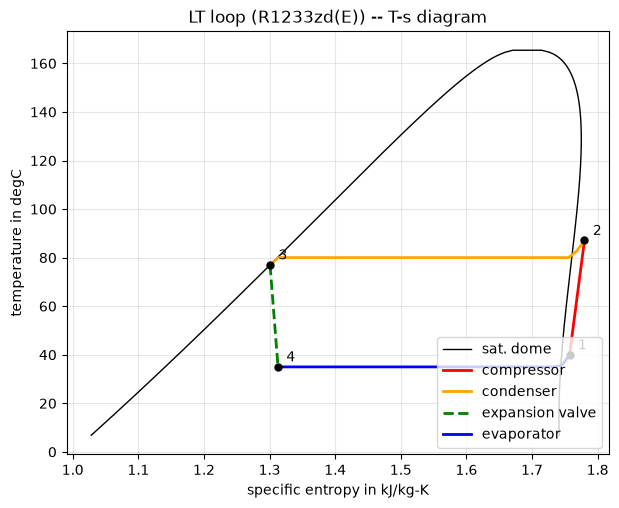

In [14]:
def conn_Ts(conn):
    p_Pa = conn.p.val * 1e5
    h_Jkg = conn.h.val * 1e3
    T = PropsSI('T', 'P', p_Pa, 'H', h_Jkg, FLUID) - 273.15
    s = PropsSI('S', 'P', p_Pa, 'H', h_Jkg, FLUID) / 1e3
    return T, s


def isobar_Ts(p_bar, h1_kJkg, h2_kJkg, n=40):
    p_Pa = p_bar * 1e5
    hs = np.linspace(h1_kJkg, h2_kJkg, n) * 1e3
    T = PropsSI('T', 'P', p_Pa, 'H', hs, FLUID) - 273.15
    s = PropsSI('S', 'P', p_Pa, 'H', hs, FLUID) / 1e3
    return T, s


T_crit = PropsSI('Tcrit', FLUID)
T_dome = np.linspace(280, T_crit - 0.3, 200)
sf = PropsSI('S', 'T', T_dome, 'Q', 0, FLUID) / 1e3
sg = PropsSI('S', 'T', T_dome, 'Q', 1, FLUID) / 1e3
T_dome_C = T_dome - 273.15

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.plot(np.concatenate([sf, sg[::-1]]), np.concatenate([T_dome_C, T_dome_C[::-1]]),
        'k-', lw=1, label='sat. dome')

states = {'1': b01, '2': b02, '3': b03, '4': b04}
pts = {k: conn_Ts(v) for k, v in states.items()}

ax.plot([pts['1'][1], pts['2'][1]], [pts['1'][0], pts['2'][0]], 'r-', lw=2, label='compressor')
T23, s23 = isobar_Ts(b02.p.val, b02.h.val, b03.h.val)
ax.plot(s23, T23, 'orange', lw=2, label='condenser')
ax.plot([pts['3'][1], pts['4'][1]], [pts['3'][0], pts['4'][0]], 'g--', lw=2, label='expansion valve')
T41, s41 = isobar_Ts(b04.p.val, b04.h.val, b01.h.val)
ax.plot(s41, T41, 'b-', lw=2, label='evaporator')

for k, (T, s) in pts.items():
    ax.plot(s, T, 'ko', ms=5)
    ax.annotate(k, (s, T), textcoords='offset points', xytext=(6, 4))

ax.set_xlabel('specific entropy in kJ/kg-K')
ax.set_ylabel('temperature in degC')
ax.set_title('LT loop (R1233zd(E)) -- T-s diagram')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.show()


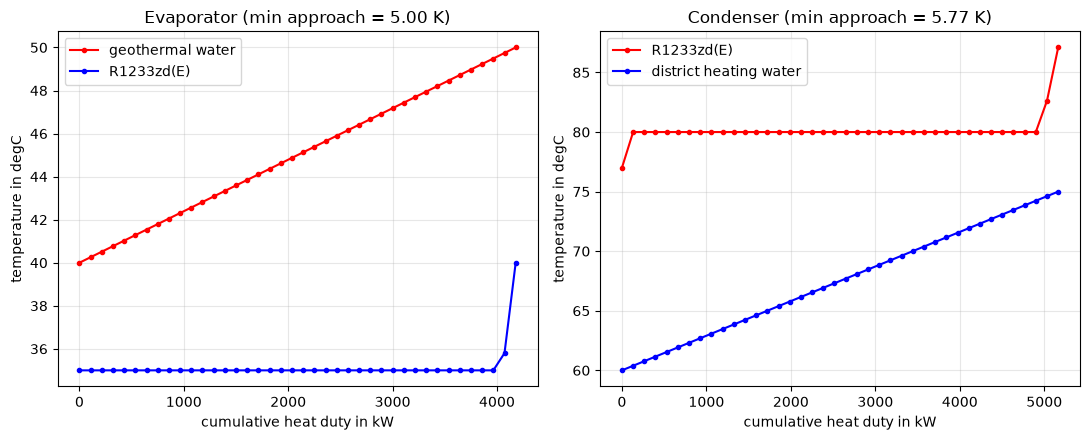

In [15]:
def counter_current_profile(m_hot, fluid_hot, p_hot_in_bar, p_hot_out_bar, h_hot_in, h_hot_out,
                             m_cold, fluid_cold, p_cold_in_bar, p_cold_out_bar, h_cold_in, h_cold_out,
                             n=40):
    Q_total = m_cold * (h_cold_out - h_cold_in)  # kW
    Q = np.linspace(0, Q_total, n)
    h_cold = h_cold_in + Q / m_cold
    h_hot = h_hot_out + Q / m_hot
    p_cold = np.linspace(p_cold_in_bar, p_cold_out_bar, n) * 1e5
    p_hot = np.linspace(p_hot_out_bar, p_hot_in_bar, n) * 1e5
    T_cold = PropsSI('T', 'P', p_cold, 'H', h_cold * 1e3, fluid_cold) - 273.15
    T_hot = PropsSI('T', 'P', p_hot, 'H', h_hot * 1e3, fluid_hot) - 273.15
    return Q, T_hot, T_cold


fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))

Q, Th, Tc = counter_current_profile(
    a02.m.val, 'water', a02.p.val, a03.p.val, a02.h.val, a03.h.val,
    b04.m.val, FLUID, b04.p.val, b01.p.val, b04.h.val, b01.h.val)
axs[0].plot(Q, Th, 'r-o', ms=3, label='geothermal water')
axs[0].plot(Q, Tc, 'b-o', ms=3, label=FLUID)
axs[0].set_title(f'Evaporator (min approach = {(Th - Tc).min():.2f} K)')
axs[0].set_xlabel('cumulative heat duty in kW')
axs[0].set_ylabel('temperature in degC')
axs[0].legend()
axs[0].grid(alpha=0.3)

Q, Th, Tc = counter_current_profile(
    b02.m.val, FLUID, b02.p.val, b03.p.val, b02.h.val, b03.h.val,
    d01.m.val, 'water', d01.p.val, d02.p.val, d01.h.val, d02.h.val)
axs[1].plot(Q, Th, 'r-o', ms=3, label=FLUID)
axs[1].plot(Q, Tc, 'b-o', ms=3, label='district heating water')
axs[1].set_title(f'Condenser (min approach = {(Th - Tc).min():.2f} K)')
axs[1].set_xlabel('cumulative heat duty in kW')
axs[1].set_ylabel('temperature in degC')
axs[1].legend()
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
